In [105]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from pyomo.environ import *
import folium
import networkx as nx
import osmnx as ox
import time
from folium.plugins import HeatMap

import importlib
import sim_utils

# ⚡ ESTO OBLIGA A PYTHON A LEER TU NUEVA VERSIÓN DE SIM_UTILS.PY
importlib.reload(sim_utils)

from sim_utils import compute_travel_time_matrix, normalize, coverage_model, risk_model, first_map, compute_mean_time, compute_efficiency, SIMULATION, compute_unprotected_ratio, plot_accessibility_results, plot_model_comparison, time_plots

# Problem statement
Suppose $k$ demand nodes (patients) and $m$ candidate locations for hospitals. The aim is to determine where to build hospitals by comparing two optimization approaches: 
1) to maximize patients's coverage
2) to minimize spatial vulnerability

## Sets
* $I$ represents the demand (patients) set.
* $J$ is the candidate hospitals' set

## Parameters
* $T_{ij}$ is the travel time from patient $i$ to hospital $j$
* $w_{ij}$ represents the spatial decay in accessibility of patient $i$ relative to hospital $j$, and it is defined as:
$$
w_{ij} = \begin{cases} 
\exp(-\gamma T_{ij}) & \text{if } T_{ij} < t' \\ 
0 & \text{if } T_{ij} \ge t' 
\end{cases}
$$
In this formulation, $\gamma$ controls how quickly accessibility decreases with increasing travel time, and can be calibrated through sensitivity analysis, empirical observations or alternative decission criteria based on the context. The parameter t' is a temporal cutoff beyond which accessibility is assumed to be negligible, ensuring that patients are only conisdered covered within a maximum travel time threhsold. The value of the parameter t' depends on the context.

## Decision variable
$x_j$ is a binary decision variable determining whether a hospital is built or not.
$$
x_j \in \{0,1\}
$$
$$
x_{j} = \begin{cases} 
1 & \text{if}\ hospital\ j\ is\ built  \\ 
0 & otherwise
\end{cases}
$$

## System metrics
### Cumulative coverage $C_i$
Represents the cumulative accessibility for patient $i$ due to all open hospitals.
$$
C_i = \sum_j w_{ij}x_j
$$

## Spatial protection
$$
P_i = \begin{cases} 
1-\exp(- C_{i}) & \text{if } C_i > 0 \\ 
0 & \text{if } C_i = 0 \\
1 & \text{if } C_i \rightarrow \infty
\end{cases}
$$

$P_i$ represents the level of protection associated with location $i$, and $C_i$ denotes the cumulative coverage or protective capacity at that location. Spatial protection allows vulnerability to be defined as $V_i=1-P_i=exp(-C_i)$, and is interpreted as the residual risk that cannot be covered by surrounding hospitals.

## Case 1: Maximize coverage
The system maximize coverage paying more attention to those regions with higher heart attack intensity.

#### Objective function
$$
max\sum_i \sum_j n_i\cdot w_{ij}\cdot x_{j}
$$
#### Implications:
1) **Centralization and clustering**: the model may tend to cluster hospitals near the high-demand zone, ignoring those where heart attack incidency is lower, creating spatial inequality.
2) **Saturation blind/Linear accumulation**: The model does not understand saturation. It treats every unit of accessibility linearly, meaning that doubling the coverage in an already well-served area yields the same reward as covering an isolated area, leading to over-allocation in the center.

## Case 2: Minimize vulnerability
The model minimize the unmitigated risk introducing a saturating effect; meaning that the first hospital openned in a specific zone drastically drops patient vulnerability, but the second or third hospitals openned in the same vecinity yields significant lower utility.
#### Objective function
$$
min\sum_i n_i \exp \left(-\sum_j w_{ij}x_j\right) 
$$

#### Implications:
1) **Descentralization and repulsion:** The model introduces a "repulsion force" between facilities. Once a high-risk node reaches good protection levels, the solver allocate remaining resources in unprotected regions.
2) **Saturation prevention**: The model prevents the over-allocation of resources in central areas, leading to a much more homogeneous, geographically distributed, and fair healthcare network.

#### Both objective functions are subject to
$$
\sum_j x_j \leq K
$$

Where $K$ is the number of built hospitals.

##### Interpretation
* Approach 1 tries to assign resources by favouring high-demand regions.
* Approach 2 tries to distribute resources ensuring protection across the entire territory, preventing over-allocation in already well-served areas.

The fundamental difference is **efficiency versus fairness**. Approach 1 aims to maximize accessibility where demand (heart attack events) is high, event if this leaves remote areas unserved. Approach 2 prioritizes geographic fairness, preventing health-cate saturation in already well-served neighborhoods, and instead allocating resources more uniformely across the entire area.

In [125]:
# Import files
boundaries = gpd.read_file('boundaries.gpkg')
spots = gpd.read_file('spots.gpkg')
problematics = [710, 723, 702, 729, 701, 740, 752, 789, 456, 415, 733, 652, 666, 828, 844, 847, 894, 276, 500, 853, 801, 887, 594, 522, 583, 589]
spots = spots.drop(index=problematics).reset_index(drop=True)
candidates = pd.read_csv('candidate_spots.csv')

# PLOT MAP
first_map(boundaries, spots, candidates)

#### Compute the cost matrix $T_{ij}$

In [4]:
# Compute cost matrix
time_matrix, G = compute_travel_time_matrix(
    demand_df=spots, 
    facility_df=candidates,
    place_name="Quebec, Quebec, Canada"
)

Mapping coordinates to network nodes...
Computing travel time matrix...
Matrix computation completed successfully.


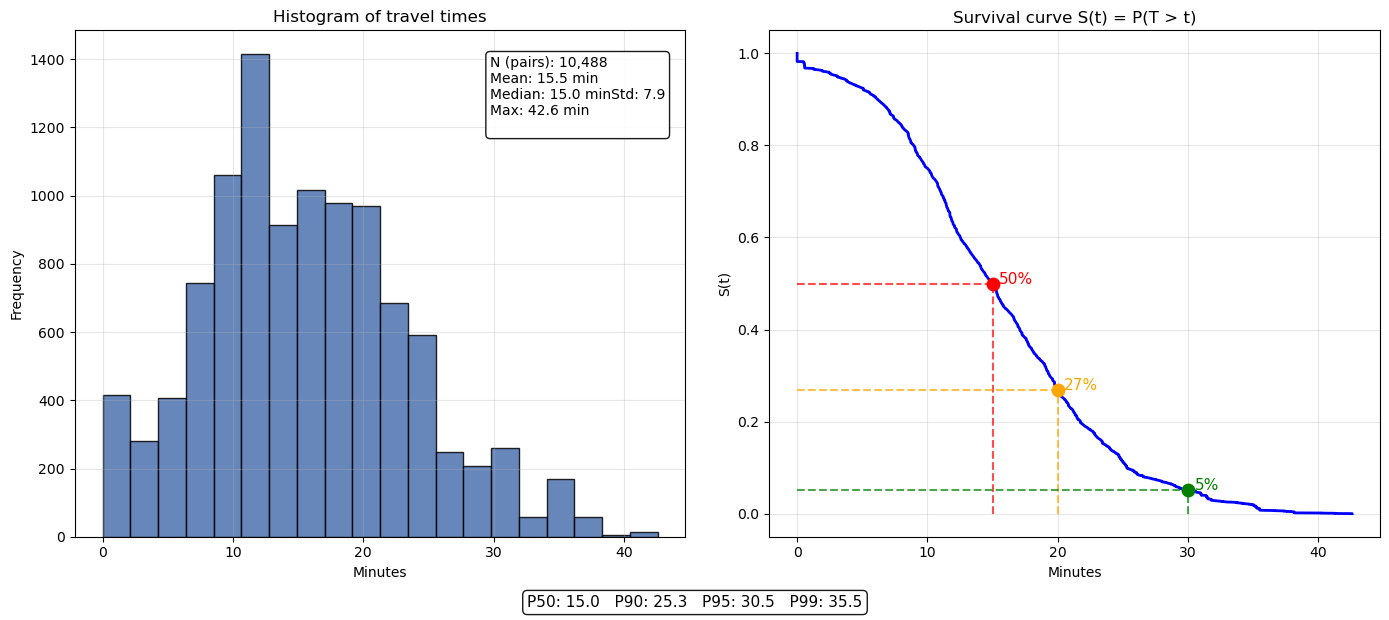

In [106]:
time_plots(time_matrix)

The survival curve illustrates that coverage drops by 50% when $t=15$ minutes. Thus, we can calibrate $\gamma$ using the **half-time method**, setting $t_{1/2}=15$.

$$
0.5 = \exp(-\gamma \cdot 15 )
$$
$$
\gamma = -\frac{ln(0.5)}{15}\approx 0.046
$$

### MODEL 1: LINEAR COVERAGE MODEL
Open more hospitals where the demand is highest! it does not matter if they cluster in the downtown.

### MODEL 2: NON-LINEAR VULNERABILITY MODEL
"Health is a right" if one district has a hospital, people are already covered, openning another hospital there is a waste of resources, let's better open then in vulnerable zones.

## Performance Assessment Metrics
For both models, the following metrics will be assessed.

### 1. System Efficency
It can be interpreted as the percentage of mitigated risk when openning extra hospitals.
$$
\eta = 1-\frac{R}{R_0}
$$
Where:
* $R$: Residual risk (after opening hospitals)
* $R_0$: Inicial risk (without hospitals)

### 2. Mean time 
It's the average time a patient takes to reach the nearest hospital 

### 3. Unprotected ratio
It's the fraction of the population that could not be covered 
$$
UR = \frac{not\ covered}{total}
$$
### 4. Gini Index
Measures coverage inequality distribution across demand locations, capturing how concentrated or dispersed accessibility is throughout Quebec.

## Optimization for different values of K

-------------------------------------
---------- COVERAGE MODEL------------
-------------------------------------
K=1 | eta=43.91% | mean time=10.90s | ratio=7.44% | duration=0.22s
K=2 | eta=67.19% | mean time=9.70s | ratio=5.49% | duration=0.24s
K=3 | eta=77.99% | mean time=9.00s | ratio=5.49% | duration=0.25s
K=4 | eta=84.33% | mean time=7.70s | ratio=5.49% | duration=0.23s
K=5 | eta=87.59% | mean time=7.70s | ratio=5.49% | duration=0.20s
K=6 | eta=89.99% | mean time=6.90s | ratio=4.81% | duration=0.23s
K=7 | eta=92.78% | mean time=6.10s | ratio=1.49% | duration=0.26s
K=8 | eta=93.44% | mean time=5.60s | ratio=1.49% | duration=0.25s
K=9 | eta=93.78% | mean time=5.60s | ratio=1.49% | duration=0.25s
K=10 | eta=94.98% | mean time=4.90s | ratio=0.92% | duration=0.16s
K=11 | eta=95.77% | mean time=4.50s | ratio=0.00% | duration=0.17s
K=12 | eta=97.18% | mean time=4.00s | ratio=0.00% | duration=0.19s
-------------------------------------
------------- RISK MODEL-------------
--------------

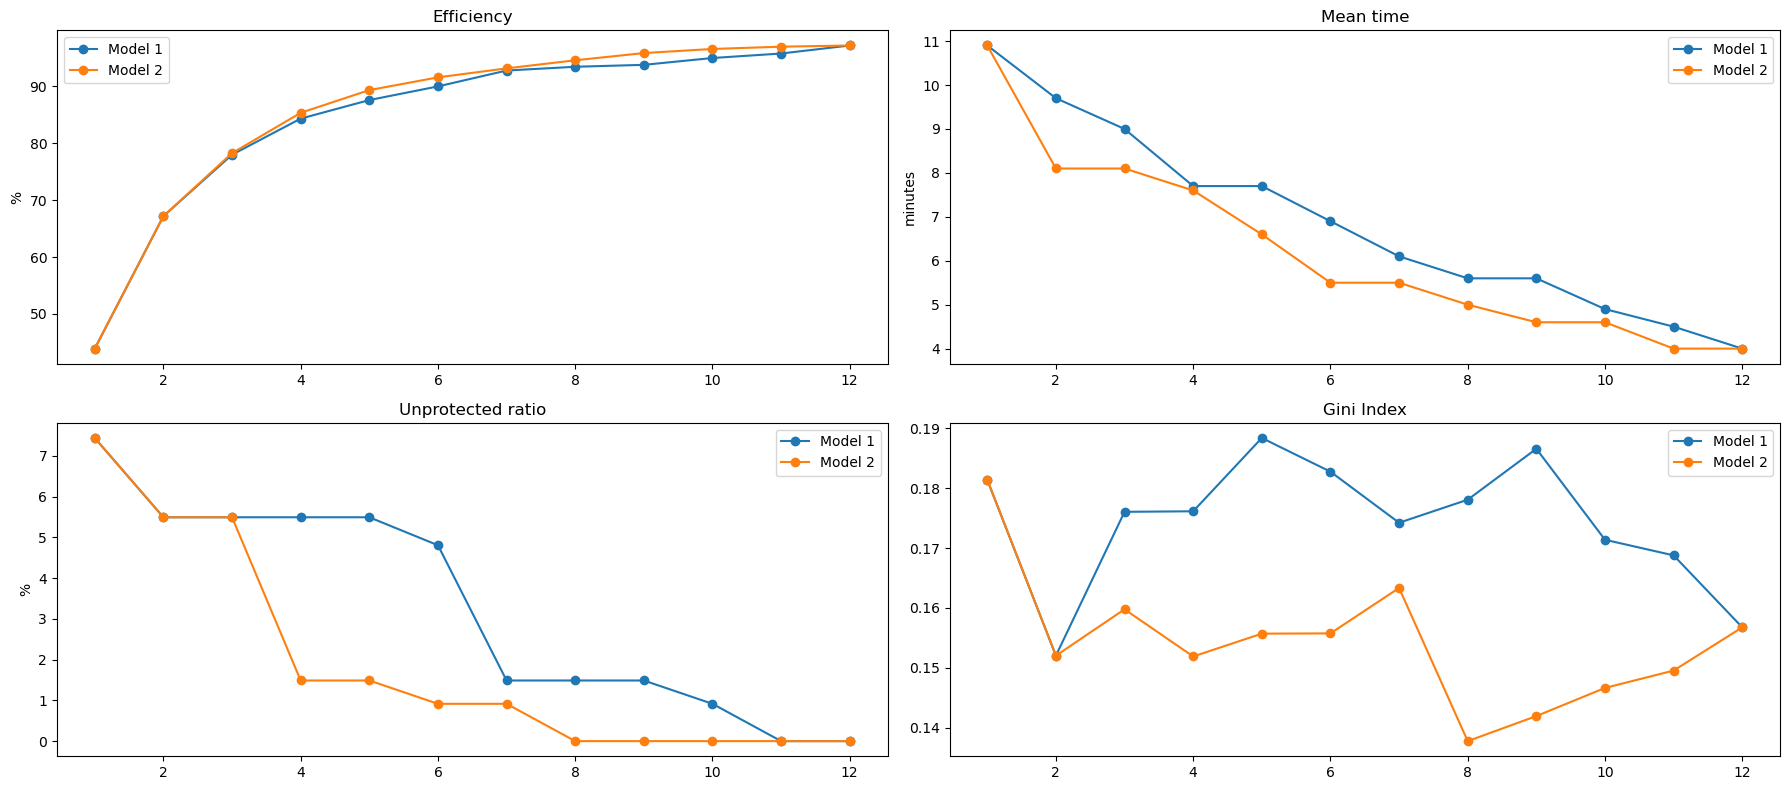

In [121]:
th = 20 # set cutoff at 20 min to ensure coverage in that radius 
results = SIMULATION(spots, candidates, time_matrix, th)

# PLOT RESULTS
_ = plot_model_comparison(results)

### Interpretation
1) **Efficiency**: Both models exhibit similar efficiency trends, reaching a plateau as the number of hospitals increases. However, while no clear inflection point is observed, $K=4$ may be a reasonable candidate, efficiency reaches ~90% and it appears to mark a point beyond which further gains become progressively smaller.
2) **Mean time**: In both models, times decreases approximately linearly with increasing $K$. However, model 2 consistently outperforms model 1, yielding lower travel times and suggesting a more uniform spatial distribution of services.
3) **Unprotected ratio**: Initially, both models produce similar values. However, beyond $K=4$, model 2 shows a marked reduction in the unprotected, suggesting that values of K>4 may significantly reduce vulnerability. This observation, however, requires further statistical validation.
4) **Gini index**: Model 2 consistently yields lower gini values than model 1, indicating a more equitable spatial distribution of healthcare accessibility and a less concentrated allocation of resources.

Overall, Model 2 achieves higher accessibility, lower travel times, and reduced inequality, indicating a more favorable performance. In addition, K=4 appears to mark a threshold beyond which further gains in efficiency become marginal, suggesting a point of diminishing returns for additional hospital placements.

### Run optimization with k=4

In [133]:
choice = 2
k = 4

if choice == 1:
    # COVERAGE MODEL OPTIMIZATION#
    model, solver = coverage_model(spots, candidates, time_matrix, th)
    
elif choice == 2:
    # RISK MODEL OPTIMIZATION
    model, solver = risk_model(spots, candidates,time_matrix , th)

# SET THE NUMBER OF HOSPITALS
model.K.set_value(k)

# SOLVE
result = solver.solve(model)

mean_time = compute_mean_time(time_matrix, spots, model, candidates)
print(f'Mean time = {mean_time} min')

Mean time = 7.6 min


In [134]:
idx = [j for j in model.J if value(model.x[j]) > 0]

chosen_hospitals = candidates.loc[idx]
ch_id = chosen_hospitals.index.tolist()
spots['nearest_time'] = [ min( time_matrix[i,ch_id]) for i in spots.index ]
chosen_hospitals

,latitude,longitude
2,46.818572,-71.233943
5,46.840790,-71.308912
10,46.885253,-71.201567
11,46.774958,-71.358367


## Plot results

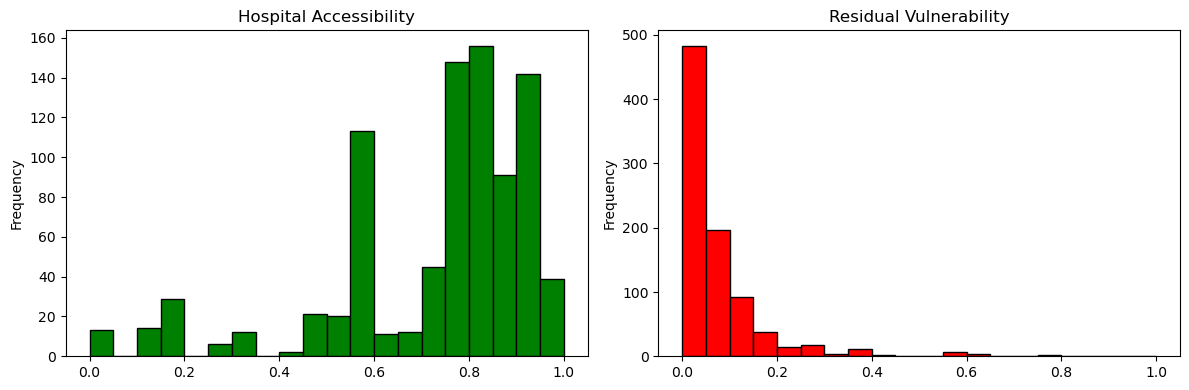

In [135]:
map_qc = plot_accessibility_results(
    spots,
    model,
    chosen_hospitals
)

map_qc